## Linear Regression Analysis in R

This notebook fits a linear regression model to examine the relationship between YearsExperience and Salary. It calculates the slope, intercept, Pearson correlation coefficient, and Mean Squared Error.

In [3]:
library(ggplot2)

dataset <- read.csv("regression_data-1.csv")

df <- data.frame(
  x = dataset$YearsExperience,
  y = dataset$Salary
)

model <- lm(y ~ x, data = df)

slope <- coef(model)[2]
intercept <- coef(model)[1]
r <- cor(df$x, df$y)
predicted <- predict(model)
mse <- mean((df$y - predicted)^2)

cat("Slope:", slope, "\n")
cat("Intercept:", intercept, "\n")
cat("Pearson correlation coefficient:", r, "\n")
cat("Mean Squared Error:", mse, "\n")

Slope: 8285.292 
Intercept: 29203.52 
Pearson correlation coefficient: 0.8860878 
Mean Squared Error: 17523844 


`geom_smooth()` using formula = 'y ~ x'


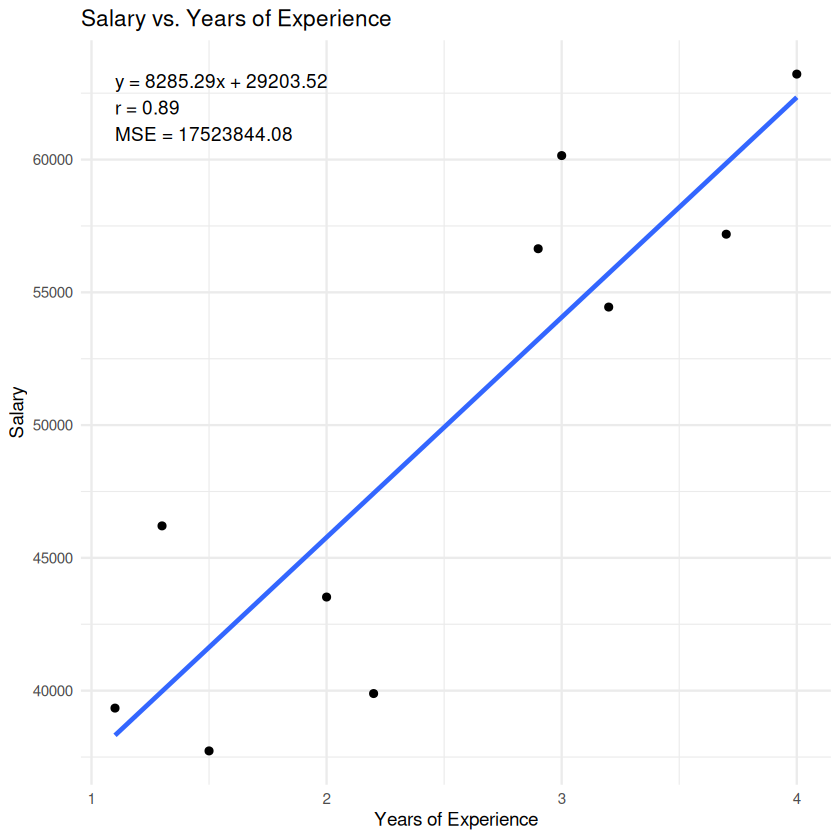

In [4]:
annotation_text <- paste0(
  "y = ", round(slope, 2),
  "x + ", round(intercept, 2),
  "\nr = ", round(r, 2),
  "\nMSE = ", round(mse, 2)
)

ggplot(df, aes(x = x, y = y)) +
  geom_point() +
  geom_smooth(method = "lm", se = FALSE) +
  annotate(
    "text",
    x = min(df$x),
    y = max(df$y),
    label = annotation_text,
    hjust = 0,
    vjust = 1
  ) +
  labs(
    title = "Salary vs. Years of Experience",
    x = "Years of Experience",
    y = "Salary"
  ) +
  theme_minimal()

## Interpretation

The regression model estimates that salary rises by approximately $8285.29 for every one-year increase in experience. The positive slope agrees with the upward pattern shown in the scatter plot.

The estimated intercept is $29203.52. It is the salary predicted by the fitted line when experience equals zero, but it may have limited practical meaning if zero years is not well represented by the observed data.

The correlation coefficient of approximately 0.886 indicates that the data points follow a fairly strong positive linear pattern. However, the points do not fall exactly on the fitted line, so experience does not explain every difference in salary.

The MSE is approximately 17.52 million. Since MSE uses squared salary units, its value appears large and is most useful when comparing this model with another model fitted to the same response variable. A smaller MSE would indicate predictions that are closer to the observed salaries.